In [79]:
from ctypes.wintypes import POINT

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



In [80]:
data = pd.read_csv("data/investigation_train_large_checked.csv")

In [81]:
data.columns[-3]

'Ja'

In [82]:
data.shape

(130000, 318)

In [83]:
print(data['checked'].value_counts())

checked
False    110496
True      19504
Name: count, dtype: int64


In [84]:
def analyze_features(df):
    binary_indices = []
    integer_indices = []
    float_indices = []
    
    for idx, col in enumerate(df.columns):
        unique_vals = df[col].unique()
        if set(unique_vals).issubset({1, 0}):
            binary_indices.append(idx)
        elif all(float(x).is_integer() for x in unique_vals):
            integer_indices.append(idx)
        else:
            float_indices.append(idx)
            
    feature_types = {
        'binary': binary_indices,
        'integer': integer_indices,
        'float': float_indices
    }
    print(f"Binary features: {len(binary_indices)}")
    print(f"Integer features: {len(integer_indices)}")
    print(f"Float features: {len(float_indices)}")
    return feature_types

In [85]:
data.columns[244]

'persoonlijke_eigenschappen_spreektaal'

In [86]:
def get_protected_feature_indices():
    protected_indices = {
        'demographic': {
            'gender': 215,
            'age': 216,
            'language': [244,245,246,247]
        },
        'location': {
            'neighborhood': list(range(6,11)),
            'district': list(range(13,22)),
            'rotterdam': [11,12]
        },
        'family': {
            'children': list(range(282,289)),
            'partner': [302,303]
        },
        'health': {
            'physical': 54,
            'mental': 55,
            'medical': [67,68,69]
        },
        'financial': {
            'problems': [53,56],
            'income': [132,133,134]
        }
    }
    return protected_indices

In [87]:
def introduce_bias(df, feature_types, protected_indices, bias_strength=3.0):
    df_biased = df.copy()

    #GENDER BIAS 
    gender_idx = protected_indices['demographic']['gender']
    feature_idx = feature_types['integer']
    gender_col = df.columns[gender_idx]
    
    important_features = feature_idx[:30]
    
    for idx in important_features:
        feature_col = df.columns[idx]
        # Women get lower values - stronger reduction with higher bias_strength
        women_mask = df[gender_col] == 1
        df_biased.loc[women_mask, feature_col] = (df_biased.loc[women_mask, feature_col] * (1.0/bias_strength)).round().astype(int)
        # Men get higher values - stronger increase with higher bias_strength
        men_mask = df[gender_col] == 0
        df_biased.loc[men_mask, feature_col] = (df_biased.loc[men_mask, feature_col] * (bias_strength/2)).round().astype(int)
    
    #AGE BIAS
    age_idx = protected_indices['demographic']['age']
    age_col = df.columns[age_idx]
    age_groups = pd.qcut(df[age_col], q=4, labels=['Young', 'Young Adult', 'Adult', 'Senior'])
    
    # Young people get lower values based on bias_strength
    young_mask = age_groups == 'Young'
    young_adult_mask = age_groups == 'Young Adult'
    for idx in important_features:
        feature_col = df.columns[idx]
        df_biased.loc[young_mask, feature_col] = (df_biased.loc[young_mask, feature_col] * (1.0/bias_strength)).round().astype(int)
        df_biased.loc[young_adult_mask, feature_col] = (df_biased.loc[young_adult_mask, feature_col] * (1.5/bias_strength)).round().astype(int)

    #LOCATION BIAS
    location_idx = protected_indices['location']['district']
    
    # Specific districts get reduced values based on bias_strength
    for district_idx in location_idx[:3]:
        district_col = df.columns[district_idx]
        district_mask = df[district_col] == 1
        
        for idx in important_features:
            feature_col = df.columns[idx]
            df_biased.loc[district_mask, feature_col] = (df_biased.loc[district_mask, feature_col] * (1.2/bias_strength)).round().astype(int)

    return df_biased

In [88]:

X = data.iloc[:, :-3]  # all rows except JA/NEE and Target column
y = data.iloc[:, -1]   # all rows only last column

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_dev, y_train, y_dev = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [89]:
feature_types = analyze_features(X_train)
protected_indices = get_protected_feature_indices()
X_train_biased = introduce_bias(X_train, feature_types, protected_indices, bias_strength=0.8)

Binary features: 132
Integer features: 183
Float features: 0


In [90]:
def visualize_gender_bias(df_original, df_biased, feature_types, protected_indices, n_features=3):
    # Set style without using deprecated seaborn-darkgrid
    plt.style.use('dark_background')
    sns.set_style("darkgrid")
    
    fig, axes = plt.subplots(1, n_features, figsize=(15, 5))
    
    gender_idx = protected_indices['demographic']['gender']
    gender_col = df_original.columns[gender_idx]
    
    for i in range(n_features):
        feature_idx = feature_types['integer'][i]
        feature_col = df_original.columns[feature_idx]
        
        # Plot original and biased distributions side by side
        data = pd.DataFrame({
            'Original': df_original[feature_col],
            'Biased': df_biased[feature_col],
            'Gender': df_original[gender_col].map({0: 'Male', 1: 'Female'})
        })
        
        # Create boxplot
        sns.boxplot(data=data.melt(id_vars='Gender'), 
                   x='Gender', 
                   y='value', 
                   hue='variable',
                   ax=axes[i],
                   palette=['lightblue', 'lightcoral'])
        
        axes[i].set_title(feature_col)
        axes[i].set_ylabel('Value')
        if i > 0:
            axes[i].set_ylabel('')
            
    plt.tight_layout()
    return fig



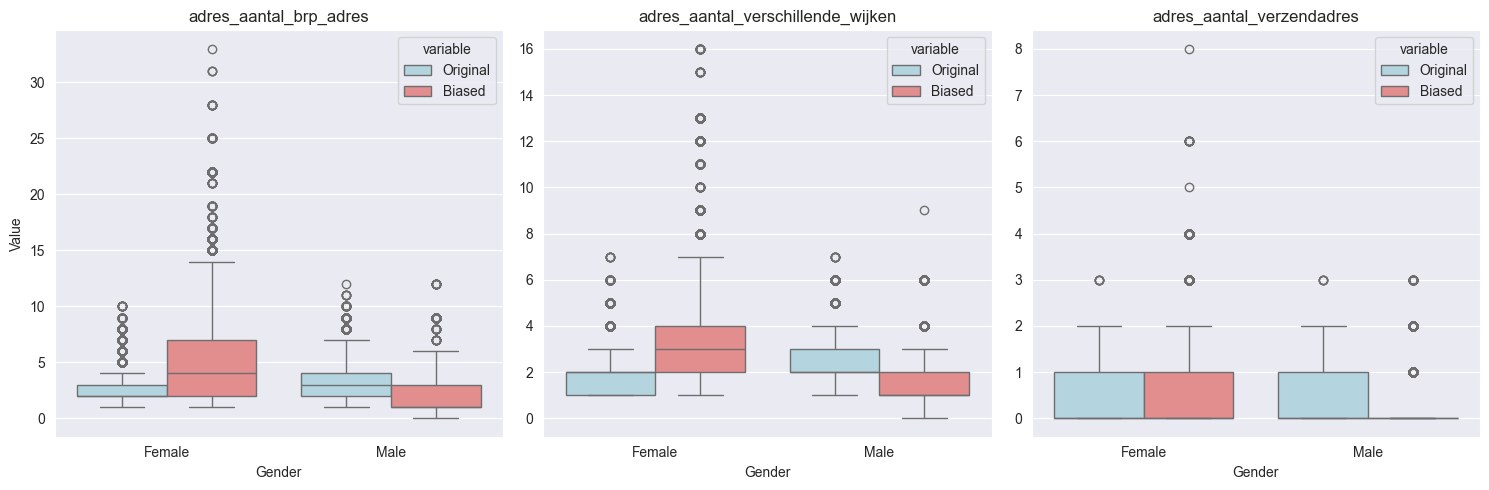

In [91]:
# Visualize the effects

fig = visualize_gender_bias(data, X_train_biased, feature_types, protected_indices)
plt.show()


In [92]:

rf_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
rf_model.fit(X_train_biased, y_train)

RandomForestClassifier(max_depth=10, min_samples_leaf=2, min_samples_split=5,
                       n_estimators=50, random_state=42)

In [93]:
def calculate_accuracy_metrics(y_true, y_pred):
    #Calculate basic accuracy metrics
    accuracy = accuracy_score(y_true, y_pred)
    report = classification_report(y_true, y_pred)
    return accuracy, report

In [94]:
def evaluate_group_discrimination(y_true, y_pred, group_mask, group_name):
    #Evaluate discrimination metrics for a specific group
    #Accuracy for this group
    group_acc = accuracy_score(y_true[group_mask], y_pred[group_mask])
    
    #Positive prediction rate for this group
    group_pos_rate = np.mean(y_pred[group_mask] == 1)
    
    return {
        f'{group_name}_accuracy': group_acc,
        f'{group_name}_pos_rate': group_pos_rate
    }

In [95]:
def evaluate_gender_bias(y_true, y_pred, X, protected_indices):
    #Evaluate gender-based discrimination
    gender_idx = protected_indices['demographic']['gender']
    gender_col = X.iloc[:, gender_idx]
    
    # metrics for each gender
    female_metrics = evaluate_group_discrimination(
        y_true, y_pred, gender_col == 1, 'female'
    )
    male_metrics = evaluate_group_discrimination(
        y_true, y_pred, gender_col == 0, 'male'
    )
    
    #calculate differences
    metrics = {
        **female_metrics,
        **male_metrics,
        'accuracy_diff_FM': female_metrics['female_accuracy'] - male_metrics['male_accuracy'],
        'pos_rate_diff_FM': female_metrics['female_pos_rate'] - male_metrics['male_pos_rate']
    }
    
    return metrics

In [96]:
def evaluate_age_bias(y_true, y_pred, X, protected_indices):
    #Evaluate age-based discrimination
    age_idx = protected_indices['demographic']['age']
    age_col = X.iloc[:, age_idx]
    
    # Create age groups
    age_groups = pd.qcut(age_col, q=4, labels=['Young', 'Young Adult', 'Adult', 'Senior'])
    
    metrics = {}
    # Get metrics for each age group
    for age_group in age_groups.unique():
        group_metrics = evaluate_group_discrimination(
            y_true, y_pred, age_groups == age_group, f'age_{age_group.lower()}'
        )
        metrics.update(group_metrics)
    
    return metrics

In [97]:
def evaluate_location_bias(y_true, y_pred, X, protected_indices):
    #Evaluate location-based discrimination
    location_idx = protected_indices['location']['district']
    metrics = {}
    
    for idx in location_idx:
        district_col = X.iloc[:, idx]
        district_name = X.columns[idx].replace('address_latest_district_', '')
        
        district_metrics = evaluate_group_discrimination(
            y_true, y_pred, district_col == 1, f'district_{district_name}'
        )
        metrics.update(district_metrics)
    
    return metrics

In [98]:
def evaluate_model(model, X, y, protected_indices, set_name=""):
    #Main evaluation function""
    y_pred = model.predict(X)
    
    #overall metrics
    accuracy, report = calculate_accuracy_metrics(y, y_pred)
    
    # Get discrimination metrics
    gender_metrics = evaluate_gender_bias(y, y_pred, X, protected_indices)
    age_metrics = evaluate_age_bias(y, y_pred, X, protected_indices)
    location_metrics = evaluate_location_bias(y, y_pred, X, protected_indices)
    
    print(f"\n--- {set_name} Set Evaluation ---")
    print(f"Overall Accuracy: {accuracy:.3f}")
    print("\nClassification Report:")
    print(report)
    
    print("\nGender Discrimination:")
    print(f"Female Accuracy: {gender_metrics['female_accuracy']:.3f}")
    print(f"Male Accuracy: {gender_metrics['male_accuracy']:.3f}")
    print(f"Accuracy Difference (F-M): {gender_metrics['accuracy_diff_FM']:.3f}")
    print(f"\nPositive Prediction Rates:")
    print(f"Female: {gender_metrics['female_pos_rate']:.3f}")
    print(f"Male: {gender_metrics['male_pos_rate']:.3f}")
    print(f"Difference (F-M): {gender_metrics['pos_rate_diff_FM']:.3f}")
    
    print("\nAge Group Discrimination:")
    for key, value in age_metrics.items():
        if 'accuracy' in key:
            print(f"{key}: {value:.3f}")
    
    print("\nLocation Discrimination:")
    for key, value in location_metrics.items():
        if 'pos_rate' in key:
            print(f"{key}: {value:.3f}")
    
    return {
        'accuracy': accuracy,
        'gender_metrics': gender_metrics,
        'age_metrics': age_metrics,
        'location_metrics': location_metrics
    }


train_metrics = evaluate_model(rf_model, X_train_biased, y_train, protected_indices, "Training")
dev_metrics = evaluate_model(rf_model, X_dev, y_dev, protected_indices, "Development")
test_metrics = evaluate_model(rf_model, X_test, y_test, protected_indices, "Test")


--- Training Set Evaluation ---
Overall Accuracy: 0.874

Classification Report:
              precision    recall  f1-score   support

       False       0.87      1.00      0.93     70743
        True       1.00      0.16      0.27     12457

    accuracy                           0.87     83200
   macro avg       0.93      0.58      0.60     83200
weighted avg       0.89      0.87      0.83     83200


Gender Discrimination:
Female Accuracy: 0.874
Male Accuracy: 0.874
Accuracy Difference (F-M): 0.001

Positive Prediction Rates:
Female: 0.023
Male: 0.025
Difference (F-M): -0.002

Age Group Discrimination:
age_young_accuracy: 0.794
age_adult_accuracy: 0.935
age_young adult_accuracy: 0.878
age_senior_accuracy: 0.891

Location Discrimination:
district_adres_recentste_wijk_charlois_pos_rate: 0.023
district_adres_recentste_wijk_delfshaven_pos_rate: 0.024
district_adres_recentste_wijk_feijenoord_pos_rate: 0.029
district_adres_recentste_wijk_ijsselmonde_pos_rate: 0.027
district_adres_recent

In [99]:
#Check relationship between features and target
importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
})
print("Top 10 most important features:")
print(importances.sort_values('importance', ascending=False).head(10))

# Check target distribution
print("\nTarget distribution:")
print(y.value_counts(normalize=True))

# Look for highest correlations
correlations = data.corr()['checked'].sort_values(ascending=False)
print("\nTop correlations with target:")
print(correlations.head())

Top 10 most important features:
                                               feature  importance
216                     persoon_leeftijd_bij_onderzoek    0.095025
276                          pla_historie_ontwikkeling    0.076003
290           relatie_overig_actueel_vorm__kostendeler    0.040995
299                         relatie_overig_kostendeler    0.037816
266             pla_hist_pla_categorie_doelstelling_16    0.036202
140                        contacten_onderwerp_no_show    0.032382
206  ontheffing_dagen_hist_vanwege_uw_medische_omst...    0.032346
181                instrument_ladder_huidig_activering    0.029096
219     persoonlijke_eigenschappen_dagen_sinds_taaleis    0.027354
179              instrument_ladder_historie_activering    0.023947

Target distribution:
checked
False    0.849969
True     0.150031
Name: proportion, dtype: float64

Top correlations with target:
checked                                     1.000000
Ja                                          0.57

In [100]:
def analyze_real_predictions(model, X_test, y_test, protected_indices):
    # Get predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]  # Probability of positive class
    
    # Gender Analysis
    gender_idx = protected_indices['demographic']['gender']
    gender = X_test.iloc[:, gender_idx]
    
    print("=== Gender Analysis ===")
    print("\nFemales:")
    female_probs = y_pred_proba[gender == 1]
    print(f"Average probability: {female_probs.mean():.3f}")
    print(f"Positive predictions: {(y_pred[gender == 1] == 1).mean():.3f}")
    
    print("\nMales:")
    male_probs = y_pred_proba[gender == 0]
    print(f"Average probability: {male_probs.mean():.3f}")
    print(f"Positive predictions: {(y_pred[gender == 0] == 1).mean():.3f}")
    
    # Age Analysis
    age_idx = protected_indices['demographic']['age']
    ages = X_test.iloc[:, age_idx]
    age_groups = pd.qcut(ages, q=4, labels=['Young', 'Young Adult', 'Adult', 'Senior'])
    
    print("\n=== Age Group Analysis ===")
    for group in age_groups.unique():
        group_mask = age_groups == group
        print(f"\n{group}:")
        print(f"Average probability: {y_pred_proba[group_mask].mean():.3f}")
        print(f"Positive predictions: {(y_pred[group_mask] == 1).mean():.3f}")
    
    # Location Analysis
    print("\n=== Location Analysis ===")
    for district_idx in protected_indices['location']['district']:
        district_name = X_test.columns[district_idx]
        district_mask = X_test.iloc[:, district_idx] == 1
        if district_mask.sum() > 0:  # Only if we have cases in this district
            print(f"\n{district_name}:")
            print(f"Average probability: {y_pred_proba[district_mask].mean():.3f}")
            print(f"Positive predictions: {(y_pred[district_mask] == 1).mean():.3f}")

# Run the analysis
analyze_real_predictions(rf_model, X_test, y_test, protected_indices)

=== Gender Analysis ===

Females:
Average probability: 0.139
Positive predictions: 0.010

Males:
Average probability: 0.160
Positive predictions: 0.017

=== Age Group Analysis ===

Young:
Average probability: 0.218
Positive predictions: 0.045

Senior:
Average probability: 0.116
Positive predictions: 0.000

Adult:
Average probability: 0.118
Positive predictions: 0.002

Young Adult:
Average probability: 0.143
Positive predictions: 0.006

=== Location Analysis ===

adres_recentste_wijk_charlois:
Average probability: 0.146
Positive predictions: 0.011

adres_recentste_wijk_delfshaven:
Average probability: 0.154
Positive predictions: 0.015

adres_recentste_wijk_feijenoord:
Average probability: 0.159
Positive predictions: 0.017

adres_recentste_wijk_ijsselmonde:
Average probability: 0.153
Positive predictions: 0.010

adres_recentste_wijk_kralingen_c:
Average probability: 0.126
Positive predictions: 0.008

adres_recentste_wijk_noord:
Average probability: 0.153
Positive predictions: 0.016

adre